# Exploratory Data Analysis — ER Wait Time Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Load Data

In [2]:
df = pd.read_csv('../data/ER Wait Time Dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (5000, 19)


,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Visit ID                            5000 non-null   object
 1   Patient ID                          5000 non-null   object
 2   Hospital ID                         5000 non-null   object
 3   Hospital Name                       5000 non-null   object
 4   Region                              5000 non-null   object
 5   Visit Date                          5000 non-null   object
 6   Day of Week                         5000 non-null   object
 7   Season                              5000 non-null   object
 8   Time of Day                         5000 non-null   object
 9   Urgency Level                       5000 non-null   object
 10  Nurse-to-Patient Ratio              5000 non-null   int64 
 11  Specialist Availability             5000 non-null   int6

In [4]:
df.describe().round(2)

,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Satisfaction
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,3.24,3.88,87.12,11.70,24.83,45.39,81.92,2.77
std,1.20,3.04,58.00,10.44,24.81,35.62,68.08,1.42
min,1.00,0.00,10.00,0.00,1.00,2.00,4.00,1.00
25%,3.00,1.00,36.00,3.00,6.00,17.00,27.00,1.00
50%,3.00,3.00,74.00,8.00,16.00,35.00,60.00,3.00
75%,4.00,6.00,138.00,18.00,36.00,66.00,122.00,4.00
max,5.00,10.00,200.00,66.00,163.00,233.00,442.00,5.00


## 2. Missing Values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print('No missing values found.')
else:
    print(missing)

No missing values found.


## 3. Target Variable — Total Wait Time

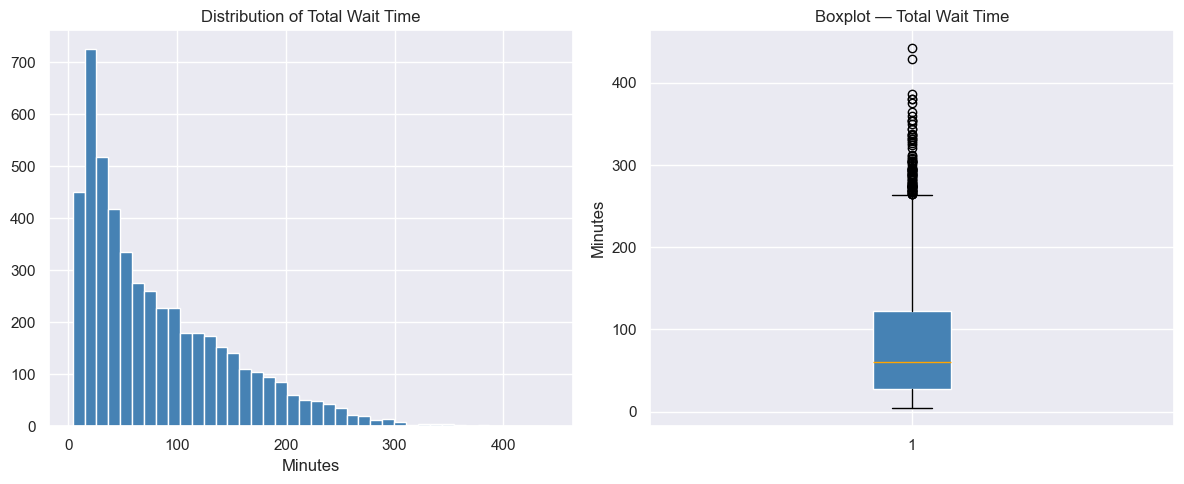

count    5000.00
mean       81.92
std        68.08
min         4.00
25%        27.00
50%        60.00
75%       122.00
max       442.00
Name: Total Wait Time (min), dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2)

axes[0].hist(df['Total Wait Time (min)'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Total Wait Time')
axes[0].set_xlabel('Minutes')

axes[1].boxplot(df['Total Wait Time (min)'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='white'),
                medianprops=dict(color='orange'))
axes[1].set_title('Boxplot — Total Wait Time')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()

print(df['Total Wait Time (min)'].describe().round(2))

## 4. Urgency Level Analysis

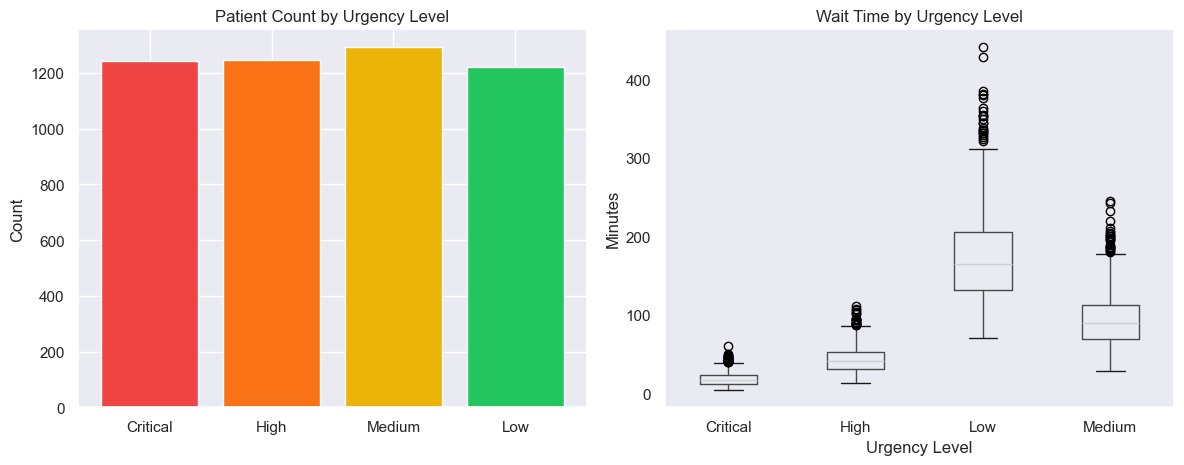

                count    mean    std   min    25%    50%    75%    max
Urgency Level                                                         
Critical       1242.0   18.35   8.11   4.0   12.0   17.0   23.0   60.0
High           1245.0   43.19  16.30  13.0   31.0   41.0   53.0  111.0
Medium         1291.0   93.70  33.77  28.0   69.5   89.0  113.0  245.0
Low            1222.0  173.54  57.00  70.0  131.0  165.0  206.0  442.0


In [7]:
urgency_order  = ['Critical', 'High', 'Medium', 'Low']
urgency_colors = {'Critical': '#ef4444', 'High': '#f97316', 'Medium': '#eab308', 'Low': '#22c55e'}

fig, axes = plt.subplots(1, 2)

counts = df['Urgency Level'].value_counts().reindex(urgency_order)
axes[0].bar(counts.index, counts.values,
            color=[urgency_colors[u] for u in counts.index])
axes[0].set_title('Patient Count by Urgency Level')
axes[0].set_ylabel('Count')

df.boxplot(column='Total Wait Time (min)', by='Urgency Level', ax=axes[1], grid=False)
axes[1].set_title('Wait Time by Urgency Level')
axes[1].set_xlabel('Urgency Level')
axes[1].set_ylabel('Minutes')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(df.groupby('Urgency Level')['Total Wait Time (min)'].describe().round(2).reindex(urgency_order))

## 5. Time Patterns

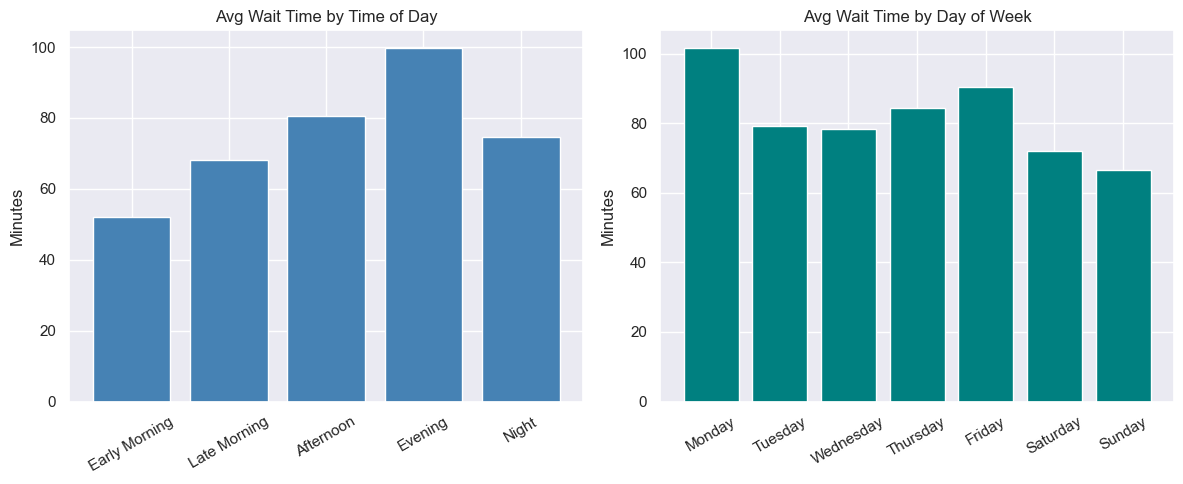

In [8]:
time_order = ['Early Morning', 'Late Morning', 'Afternoon', 'Evening', 'Night']
day_order  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2)

tod_avg = df.groupby('Time of Day')['Total Wait Time (min)'].mean().reindex(time_order)
axes[0].bar(tod_avg.index, tod_avg.values, color='steelblue')
axes[0].set_title('Avg Wait Time by Time of Day')
axes[0].set_ylabel('Minutes')
axes[0].tick_params(axis='x', rotation=30)

dow_avg = df.groupby('Day of Week')['Total Wait Time (min)'].mean().reindex(day_order)
axes[1].bar(dow_avg.index, dow_avg.values, color='teal')
axes[1].set_title('Avg Wait Time by Day of Week')
axes[1].set_ylabel('Minutes')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6. Seasonal & Regional Patterns

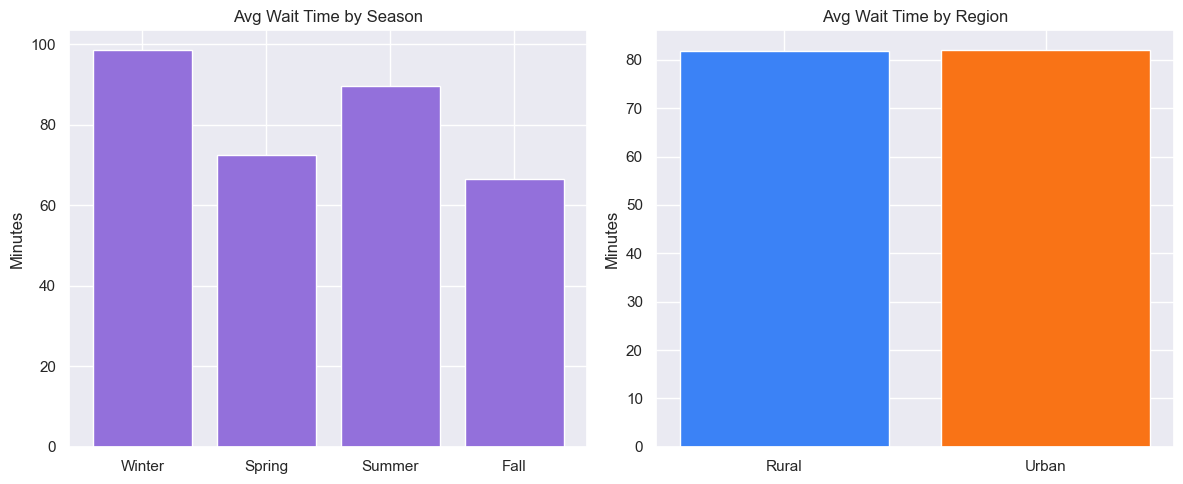

In [9]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

fig, axes = plt.subplots(1, 2)

season_avg = df.groupby('Season')['Total Wait Time (min)'].mean().reindex(season_order)
axes[0].bar(season_avg.index, season_avg.values, color='mediumpurple')
axes[0].set_title('Avg Wait Time by Season')
axes[0].set_ylabel('Minutes')

region_avg = df.groupby('Region')['Total Wait Time (min)'].mean()
axes[1].bar(region_avg.index, region_avg.values, color=['#3b82f6', '#f97316'])
axes[1].set_title('Avg Wait Time by Region')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()

## 7. Numeric Feature Correlations

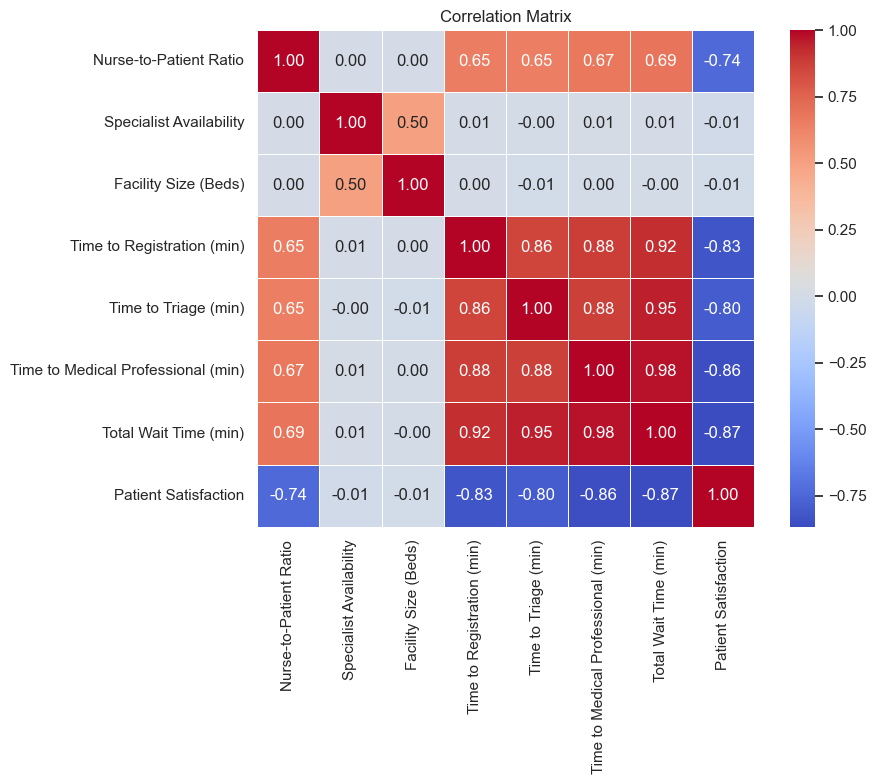

In [10]:
numeric_cols = [
    'Nurse-to-Patient Ratio',
    'Specialist Availability',
    'Facility Size (Beds)',
    'Time to Registration (min)',
    'Time to Triage (min)',
    'Time to Medical Professional (min)',
    'Total Wait Time (min)',
    'Patient Satisfaction'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 8. Patient Outcome Distribution

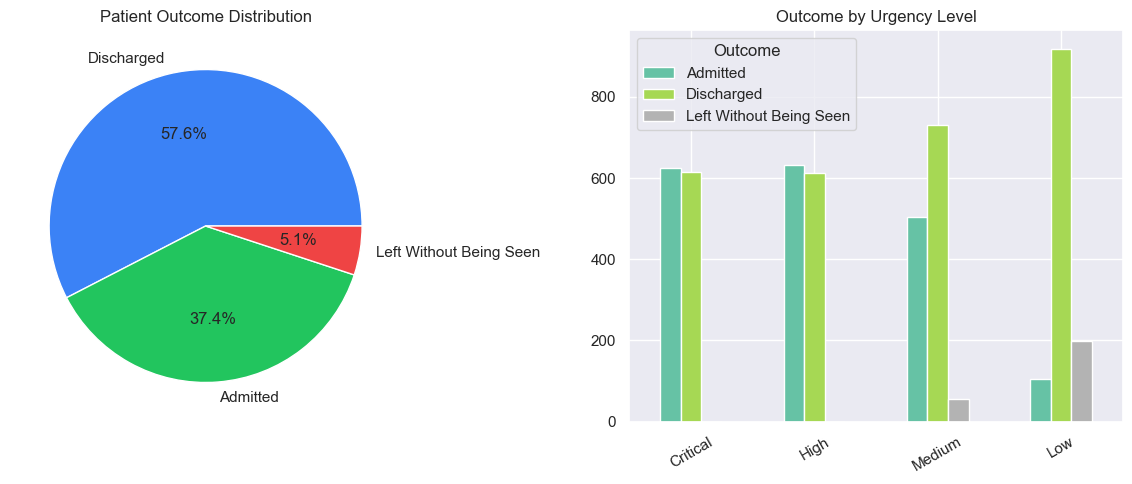

In [11]:
fig, axes = plt.subplots(1, 2)

outcome_counts = df['Patient Outcome'].value_counts()
axes[0].pie(outcome_counts.values, labels=outcome_counts.index,
            autopct='%1.1f%%', colors=['#3b82f6', '#22c55e', '#ef4444'])
axes[0].set_title('Patient Outcome Distribution')

outcome_by_urgency = df.groupby(['Urgency Level', 'Patient Outcome']).size().unstack(fill_value=0)
outcome_by_urgency.reindex(urgency_order).plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Outcome by Urgency Level')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.show()

## 9. Wait Time Sub-Components

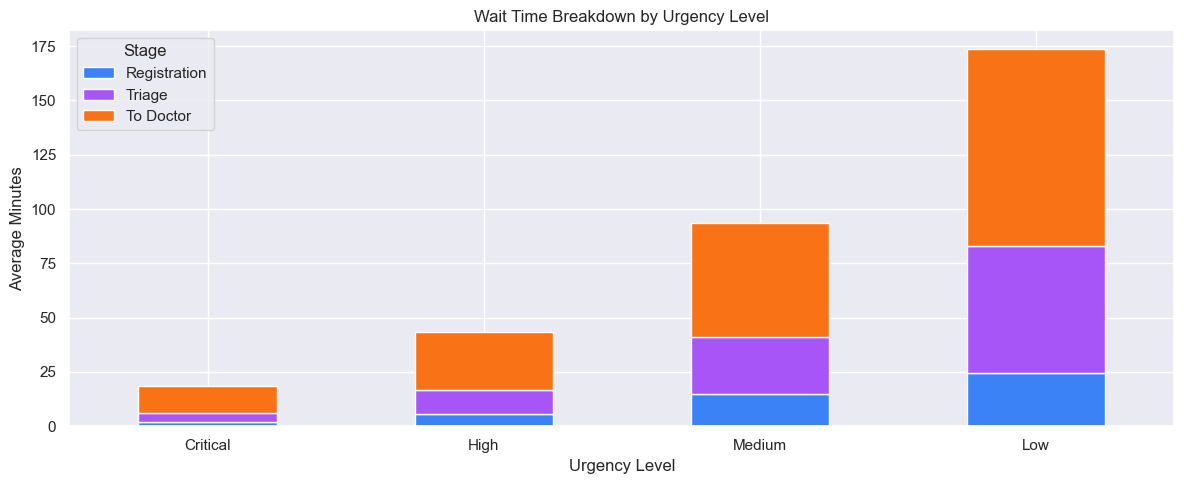

In [12]:
sub_times = [
    'Time to Registration (min)',
    'Time to Triage (min)',
    'Time to Medical Professional (min)'
]

avg_by_urgency = df.groupby('Urgency Level')[sub_times].mean().reindex(urgency_order)
avg_by_urgency.columns = ['Registration', 'Triage', 'To Doctor']

avg_by_urgency.plot(kind='bar', stacked=True, color=['#3b82f6', '#a855f7', '#f97316'])
plt.title('Wait Time Breakdown by Urgency Level')
plt.ylabel('Average Minutes')
plt.xlabel('Urgency Level')
plt.xticks(rotation=0)
plt.legend(title='Stage')
plt.tight_layout()
plt.show()

## 10. Key Insights Summary

In [13]:
print('=== KEY INSIGHTS FOR ML MODEL ===')
print()

print('-- Avg Wait Time by Urgency Level --')
print(df.groupby('Urgency Level')['Total Wait Time (min)'].mean().reindex(urgency_order).round(1))
print()

print('-- Urgency Level Distribution (%) --')
print((df['Urgency Level'].value_counts(normalize=True) * 100).reindex(urgency_order).round(1))
print()

print('-- Admission Rate by Urgency Level (%) --')
admission = df[df['Patient Outcome'] == 'Admitted'].groupby('Urgency Level').size()
total     = df.groupby('Urgency Level').size()
print(((admission / total) * 100).reindex(urgency_order).round(1))
print()

print('-- Correlation with Total Wait Time --')
print(df[numeric_cols].corr()['Total Wait Time (min)'].drop('Total Wait Time (min)').sort_values().round(3))

=== KEY INSIGHTS FOR ML MODEL ===

-- Avg Wait Time by Urgency Level --
Urgency Level
Critical     18.4
High         43.2
Medium       93.7
Low         173.5
Name: Total Wait Time (min), dtype: float64

-- Urgency Level Distribution (%) --
Urgency Level
Critical    24.8
High        24.9
Medium      25.8
Low         24.4
Name: proportion, dtype: float64

-- Admission Rate by Urgency Level (%) --
Urgency Level
Critical    50.4
High        50.8
Medium      39.0
Low          8.7
dtype: float64

-- Correlation with Total Wait Time --
Patient Satisfaction                 -0.865
Facility Size (Beds)                 -0.004
Specialist Availability               0.007
Nurse-to-Patient Ratio                0.688
Time to Registration (min)            0.924
Time to Triage (min)                  0.954
Time to Medical Professional (min)    0.976
Name: Total Wait Time (min), dtype: float64
